In [1]:
# 1. Install and load the SQL extension
!pip install ipython-sql
%load_ext sql

# 2. Read your Kepler CSV file using pandas
import pandas as pd
import glob
import sqlite3

# Automatically locate the file in the Kaggle directory
csv_file = glob.glob('/kaggle/input/**/*.csv', recursive=True)[0]
kepler_df = pd.read_csv(csv_file)

# 3. Save the data into a SQLite database file
conn = sqlite3.connect('kepler_project.db')
kepler_df.to_sql('kepler', conn, if_exists='replace', index=False)
conn.close()

# 4. Connect the SQL magic engine to that exact database file
%sql sqlite:///kepler_project.db

print("Step 1 Complete: Database linked successfully!")

Step 1 Complete: Database linked successfully!


In [2]:
%config SqlMagic.autopandas = True
%config SqlMagic.feedback = False
%config SqlMagic.style = '_DEPRECATED_DEFAULT'

print("Step 2 Complete: Display bug bypassed!")

Step 2 Complete: Display bug bypassed!


In [3]:
# Drops pre-existing tables to prevent replication errors and re-records the setup view
%sql DROP TABLE IF EXISTS clean_kepler;

cleaning_query = """
CREATE TABLE clean_kepler AS 
SELECT 
    rowid, 
    kepid, 
    kepoi_name, 
    kepler_name, 
    koi_disposition, 
    koi_score, 
    koi_period, 
    koi_prad, 
    koi_teq, 
    koi_steff, 
    koi_slogg, 
    koi_srad, 
    koi_kepmag 
FROM kepler 
WHERE koi_disposition != 'FALSE POSITIVE' 
  AND koi_prad IS NOT NULL 
  AND koi_teq IS NOT NULL 
  AND koi_steff IS NOT NULL;
"""

%sql $cleaning_query

# Quick validation check to confirm view initialization
test_df = %sql SELECT * FROM clean_kepler LIMIT 5
test_df

 * sqlite:///kepler_project.db
 * sqlite:///kepler_project.db
 * sqlite:///kepler_project.db


,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_score,koi_period,koi_prad,koi_teq,koi_steff,koi_slogg,koi_srad,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,1.000,9.488036,2.26,793.0,5455.0,4.467,0.927,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,0.969,54.418383,2.83,443.0,5455.0,4.467,0.927,15.347
2,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,1.000,2.525592,2.75,1406.0,6031.0,4.438,1.046,15.509
3,6,10872983,K00756.01,Kepler-228 d,CONFIRMED,1.000,11.094321,3.90,835.0,6046.0,4.486,0.972,15.714
4,7,10872983,K00756.02,Kepler-228 c,CONFIRMED,1.000,4.134435,2.77,1160.0,6046.0,4.486,0.972,15.714


In [4]:
query_mission_1 = """
SELECT 
    kepoi_name, 
    kepler_name, 
    koi_disposition, 
    koi_period, 
    koi_prad AS earth_radii, 
    koi_teq AS planet_temp_kelvin 
FROM clean_kepler 
WHERE koi_prad BETWEEN 0.5 AND 2.0 
  AND koi_teq BETWEEN 200 AND 373 
ORDER BY koi_prad ASC;
"""

earth_candidates = %sql $query_mission_1
earth_candidates

 * sqlite:///kepler_project.db


,kepoi_name,kepler_name,koi_disposition,koi_period,earth_radii,planet_temp_kelvin
0,K07617.01,None,CANDIDATE,12.928455,0.64,343.0
1,K08174.01,None,CANDIDATE,295.060660,0.64,233.0
2,K04290.01,Kepler-1582 b,CONFIRMED,4.838095,0.79,354.0
3,K03497.01,Kepler-1512 b,CONFIRMED,20.359719,0.80,276.0
4,K01404.02,None,CANDIDATE,18.906092,0.87,336.0
...,...,...,...,...,...,...
147,K00775.03,Kepler-52 d,CONFIRMED,36.445400,1.99,332.0
148,K05276.01,None,CANDIDATE,220.720142,2.00,235.0
149,K05135.01,None,CANDIDATE,314.765374,2.00,217.0
150,K05657.01,None,CANDIDATE,284.699924,2.00,293.0


In [5]:
query_mission_2 = """
SELECT 
    CASE 
        WHEN koi_prad < 1.2 THEN 'Rocky/Earth-sized' 
        WHEN koi_prad BETWEEN 1.2 AND 2.0 THEN 'Super-Earth' 
        WHEN koi_prad BETWEEN 2.0 AND 4.0 THEN 'Sub-Neptune' 
        WHEN koi_prad BETWEEN 4.0 AND 10.0 THEN 'Neptune-like' 
        ELSE 'Gas Giant' 
    END AS planet_type, 
    COUNT(*) AS total_discovered, 
    ROUND(AVG(koi_period), 2) AS avg_orbital_year_days 
FROM clean_kepler 
GROUP BY planet_type 
ORDER BY total_discovered DESC;
"""

cosmic_inventory = %sql $query_mission_2
cosmic_inventory

 * sqlite:///kepler_project.db


,planet_type,total_discovered,avg_orbital_year_days
0,Sub-Neptune,1554,144.48
1,Super-Earth,1424,34.67
2,Rocky/Earth-sized,824,17.50
3,Neptune-like,370,99.23
4,Gas Giant,305,78.12


In [6]:
query_mission_3 = """
SELECT 
    kepid, 
    COUNT(*) AS planet_count, 
    ROUND(AVG(koi_period), 2) AS avg_orbital_period, 
    MIN(koi_prad) AS smallest_planet_radius, 
    MAX(koi_prad) AS largest_planet_radius 
FROM clean_kepler 
GROUP BY kepid 
HAVING COUNT(*) > 1 \
ORDER BY planet_count DESC \
LIMIT 10;
"""

multi_planet_systems = %sql $query_mission_3
multi_planet_systems

 * sqlite:///kepler_project.db


,kepid,planet_count,avg_orbital_period,smallest_planet_radius,largest_planet_radius
0,11442793,7,119.22,1.29,10.89
1,11709124,6,177.31,1.32,7.89
2,10187017,6,14.78,0.51,2.48
3,6541920,6,40.51,1.84,4.12
4,11968463,5,23.12,1.64,3.12
5,11497958,5,26.81,1.06,1.52
6,10397751,5,3.62,0.57,0.70
7,10122538,5,30.43,2.20,3.47
8,9787239,5,8.21,1.23,2.17
9,9458613,5,22.69,1.85,4.76


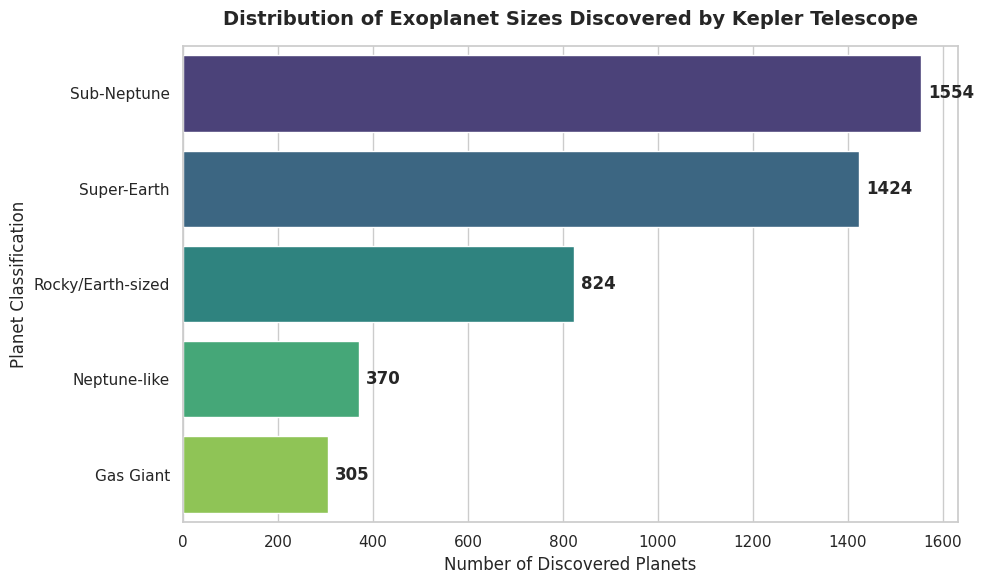

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x='total_discovered', 
    y='planet_type', 
    data=cosmic_inventory, 
    palette='viridis',
    hue='planet_type',
    legend=False
)

plt.title('Distribution of Exoplanet Sizes Discovered by Kepler Telescope', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Number of Discovered Planets', fontsize=12)
plt.ylabel('Planet Classification', fontsize=12)

for i in ax.containers:
    ax.bar_label(i, padding=5, fontweight='bold')

plt.tight_layout()
plt.show()